# Análisis PESTEL (diagrama tipo MN–MP)

Este cuaderno genera un diagrama de evaluación ordinal por factores PESTEL.

Escala:
- MN = 1 (Muy negativo)
- N  = 2 (Negativo)
- I  = 3 (Intermedio)
- P  = 4 (Positivo)
- MP = 5 (Muy positivo)

Salida:
- Figura exportada a `data/processed/figures/pestel_diagrama.png`


In [71]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 130


## 1) Dataset PESTEL (edita aquí)

Puedes:
- Mantenerlo en el cuaderno (lista de dicts)
- O cargarlo desde CSV/Excel si lo prefieres


In [ ]:
rows = [

    # ======================
    # POLÍTICOS
    # ======================
    {"dimension": "F. POLÍTICOS", "factor": "Calendario electoral municipal (2027)", "value": "N"},
    {"dimension": "F. POLÍTICOS", "factor": "Fragmentación y alternancia política local", "value": "N"},
    {"dimension": "F. POLÍTICOS", "factor": "Dependencia de autorizaciones administrativas", "value": "MN"},
    {"dimension": "F. POLÍTICOS", "factor": "Riesgo regulatorio ante cambios de gobierno", "value": "N"},

    # ======================
    # ECONÓMICOS
    # ======================
    {"dimension": "F. ECONÓMICOS", "factor": "Inflación estabilizada en entorno 2–3%", "value": "I"},
    {"dimension": "F. ECONÓMICOS", "factor": "Tipos de interés superiores a 2016–2021", "value": "N"},
    {"dimension": "F. ECONÓMICOS", "factor": "Condiciones crediticias prudentes (>3%)", "value": "N"},
    {"dimension": "F. ECONÓMICOS", "factor": "Euríbor estabilizado en entorno 2–2,5%", "value": "I"},
    {"dimension": "F. ECONÓMICOS", "factor": "Sensibilidad del proyecto al coste financiero", "value": "N"},

    # ======================
    # SOCIALES
    # ======================
    {"dimension": "F. SOCIALES", "factor": "Crecimiento demográfico nacional y regional", "value": "P"},
    {"dimension": "F. SOCIALES", "factor": "Fragmentación de los hogares", "value": "P"},
    {"dimension": "F. SOCIALES", "factor": "Desajuste entre formación de hogares y vivienda construida", "value": "MP"},
    {"dimension": "F. SOCIALES", "factor": "Dinámicas periurbanas favorables", "value": "P"},
    {"dimension": "F. SOCIALES", "factor": "Tensión en el mercado del alquiler", "value": "P"},
    {"dimension": "F. SOCIALES", "factor": "Cambio de preferencias post-pandemia", "value": "P"},
    {"dimension": "F. SOCIALES", "factor": "Segmentación creciente de la demanda", "value": "I"},

    # ======================
    # TECNOLÓGICOS
    # ======================
    {"dimension": "F. TECNOLÓGICOS", "factor": "Digitalización administrativa", "value": "I"},
    {"dimension": "F. TECNOLÓGICOS", "factor": "Modelización y análisis de datos inmobiliarios", "value": "P"},
    {"dimension": "F. TECNOLÓGICOS", "factor": "Tecnologías constructivas y eficiencia energética", "value": "P"},
    {"dimension": "F. TECNOLÓGICOS", "factor": "Comercialización digital", "value": "P"},

    # ======================
    # LEGALES
    # ======================
    {"dimension": "F. LEGALES", "factor": "Modificación del planeamiento en tramitación", "value": "N"},
    {"dimension": "F. LEGALES", "factor": "Dependencia de licencias y autorizaciones", "value": "MN"},
    {"dimension": "F. LEGALES", "factor": "Marco regulatorio de vivienda y alquiler", "value": "I"},
    {"dimension": "F. LEGALES", "factor": "Exigencias técnicas sectoriales (CTE)", "value": "I"},
    {"dimension": "F. LEGALES", "factor": "Riesgo de cambios normativos", "value": "N"},

    # ======================
    # AMBIENTALES
    # ======================
    {"dimension": "F. AMBIENTALES", "factor": "Exigencias de eficiencia energética (nZEB)", "value": "I"},
    {"dimension": "F. AMBIENTALES", "factor": "Certificaciones y construcción sostenible", "value": "I"},
    {"dimension": "F. AMBIENTALES", "factor": "Atractivo climático comparativo del norte peninsular", "value": "MP"},
    {"dimension": "F. AMBIENTALES", "factor": "Cumplimiento normativa ambiental", "value": "I"},
    {"dimension": "F. AMBIENTALES", "factor": "Tendencia regulatoria europea climática", "value": "I"},
]


df = pd.DataFrame(rows)
df.head()

,dimension,factor,value
0,F. POLÍTICOS,Calendario electoral municipal (2027),N
1,F. POLÍTICOS,Fragmentación y alternancia política local,N
2,F. POLÍTICOS,Dependencia de autorizaciones administrativas,MN
3,F. POLÍTICOS,Riesgo regulatorio ante cambios de gobierno,N
4,F. ECONÓMICOS,Inflación estabilizada en entorno 2–3%,I


## 2) Normalización de la escala MN–MP

Se convierte la escala cualitativa a valores numéricos 1..5.


In [73]:
scale_map = {"MN": 1, "N": 2, "I": 3, "P": 4, "MP": 5}

def to_num(x):
    if pd.isna(x):
        return None
    if isinstance(x, (int, float)):
        return int(x)
    x_str = str(x).strip().upper()
    if x_str in scale_map:
        return scale_map[x_str]
    raise ValueError(f"Valor inválido '{x}'. Usa MN/N/I/P/MP o 1..5")

df["score"] = df["value"].apply(to_num)

# orden de aparición (importante para el diagrama)
df["y"] = range(len(df))
df[["dimension", "factor", "value", "score"]].head()

,dimension,factor,value,score
0,F. POLÍTICOS,Calendario electoral municipal (2027),N,2
1,F. POLÍTICOS,Fragmentación y alternancia política local,N,2
2,F. POLÍTICOS,Dependencia de autorizaciones administrativas,MN,1
3,F. POLÍTICOS,Riesgo regulatorio ante cambios de gobierno,N,2
4,F. ECONÓMICOS,Inflación estabilizada en entorno 2–3%,I,3


## 3) Diagrama tipo MN–MP

Se genera un gráfico con:
- Eje X: MN, N, I, P, MP
- Eje Y: factores (ordenados)
- Puntos y línea conectando


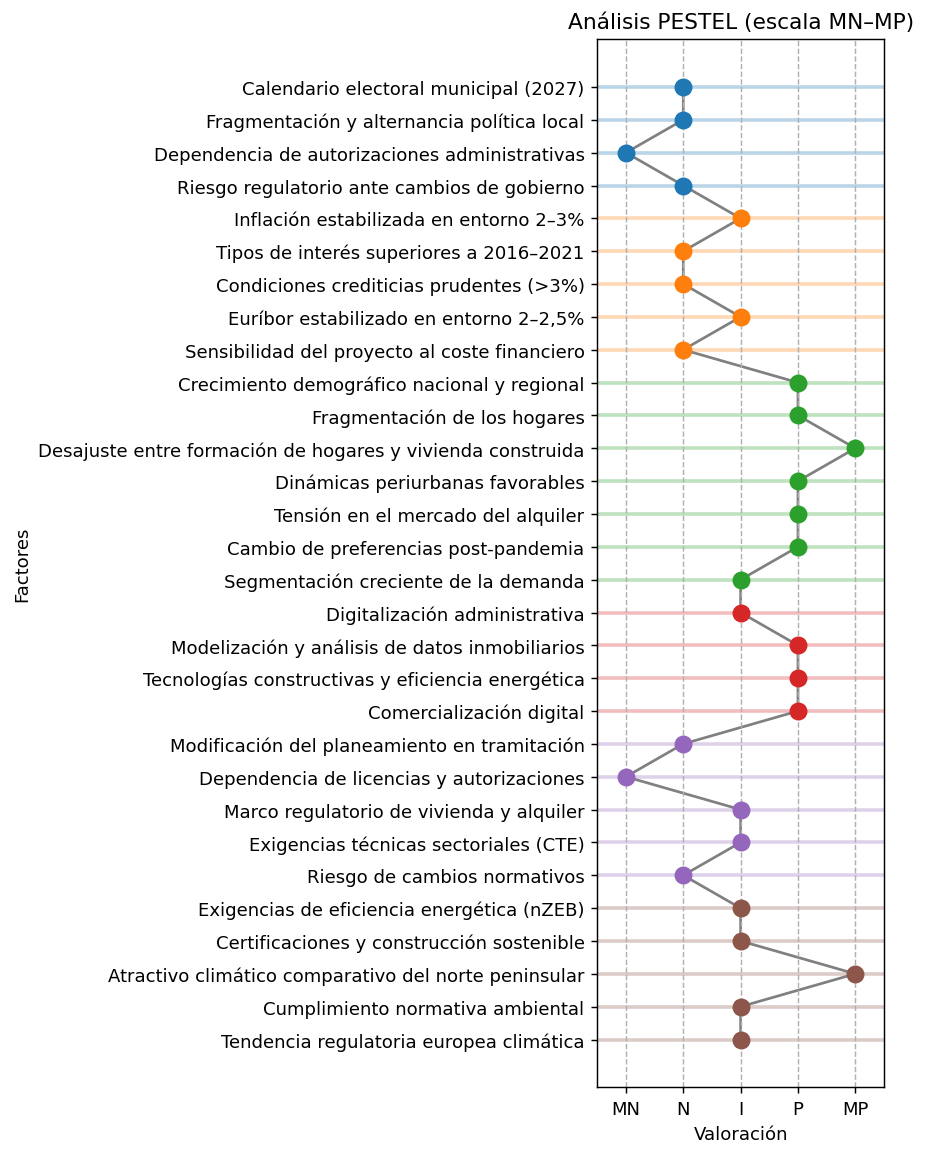

In [ ]:
x_ticks = [1, 2, 3, 4, 5]
x_labels = ["MN", "N", "I", "P", "MP"]

color_map = {
    "F. POLÍTICOS": "tab:blue",
    "F. ECONÓMICOS": "tab:orange",
    "F. SOCIALES": "tab:green",
    "F. TECNOLÓGICOS": "tab:red",
    "F. LEGALES": "tab:purple",
    "F. AMBIENTALES": "tab:brown"
}

fig, ax = plt.subplots(figsize=(7,9))

# Línea global que conecta todos los puntos
ax.plot(df["score"], df["y"], color="grey", linewidth=1.5, zorder=1)

# Dibujar líneas horizontales coloreadas por dimensión
for _, row in df.iterrows():
    ax.hlines(
        y=row["y"],
        xmin=0.5,
        xmax=5.5,
        color=color_map.get(row["dimension"], "gray"),
        alpha=0.3,          # baja opacidad
        linewidth=2,
        zorder=0
    )

# Puntos coloreados por dimensión
for dimension, group in df.groupby("dimension", sort=False):
    ax.scatter(
        group["score"],
        group["y"],
        label=dimension,
        color=color_map.get(dimension, "gray"),
        s=80,
        zorder=3
    )

# Ejes
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlim([0.5, 5.5])
ax.grid(axis="x", linestyle="--")

ax.set_yticks(df["y"])
ax.set_yticklabels(df["factor"])
ax.invert_yaxis()

ax.set_xlabel("Valoración")
ax.set_title("Análisis PESTEL (escala MN–MP)")

plt.tight_layout()
plt.show()


## 4) Exportar figura

Guarda la imagen en `data/processed/figures/`.


In [75]:
out_dir = Path("../data/processed/figures")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "pestel_diagrama.png"

# Re-generar figura para guardar (evitas depender del estado del backend)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["score"], df["y"], marker="o")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_yticks(df["y"]) 
ax.set_yticklabels(df["factor"])
ax.invert_yaxis()
ax.grid(True, axis="x")
ax.grid(False, axis="y")
ax.set_xlabel("Valoración")
ax.set_ylabel("Factores")
ax.set_title("Análisis PESTEL (escala MN–MP)")
plt.tight_layout()
fig.savefig(out_path, bbox_inches="tight")
plt.close(fig)

print(f"Figura guardada en: {out_path.resolve()}")

Figura guardada en: C:\Users\PDE6221\Documents\BezanillaSL\data\processed\figures\pestel_diagrama.png


## 5) (Opcional) Añadir separadores por dimensión

Si quieres que se vea como tabla PESTEL por bloques (Políticos, Económicos, etc.), se puede añadir una línea horizontal cuando cambie `dimension`.
Dime si lo quieres y te lo dejo listo.